# HTTP Methods

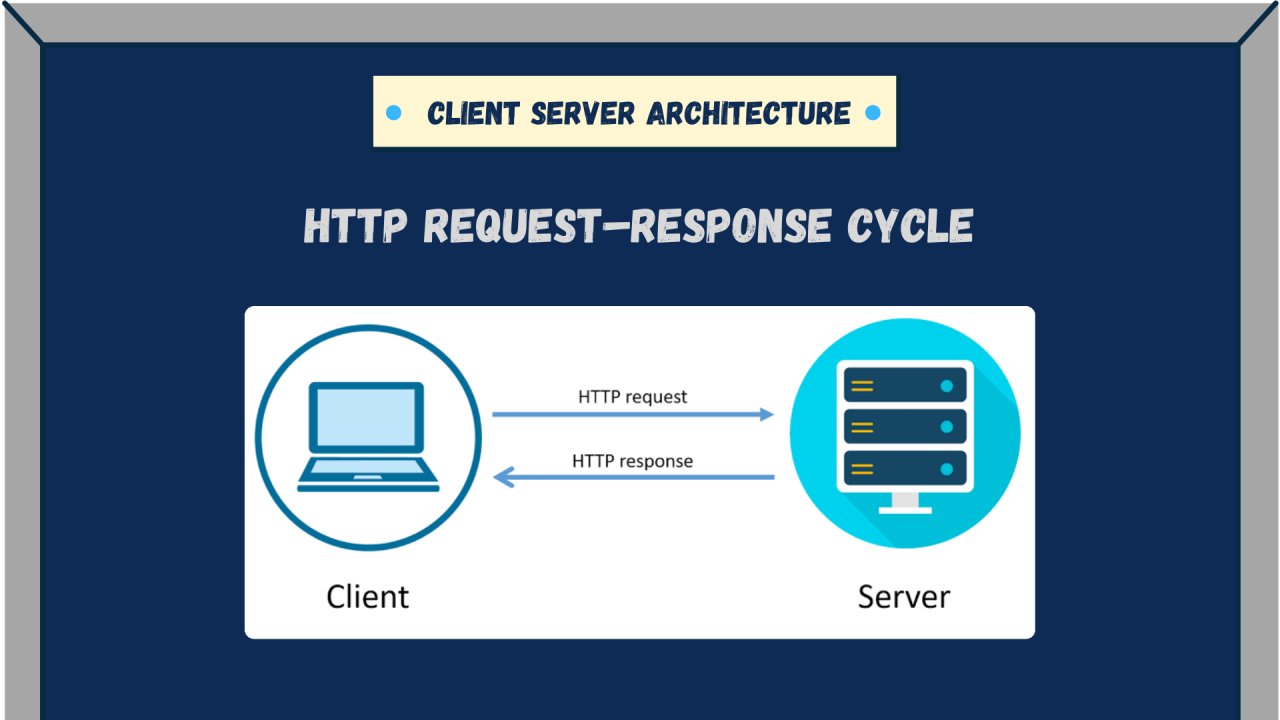

It's the language that clients and servers use to talk to each other. 
<br> **HTTP methods** tell the server what action you want to perform on a resource.

## Types of HTTP methods

#### GET — "Give me the data"

GET is the most fundamental HTTP method. Its entire purpose is to retrieve information from the server without changing anything. Think of it like reading a book in a library you pick it up, read it, and put it back. 

#### POST
POST is used to send data to the server to create a new resource. Unlike GET, POST carries its data inside the request body.
<BR> For example: When you submit a registration form, place an order, or upload a file — that is a POST request. 
<br> The most critical thing to understand about POST is that it is not **idempotent**. If  accidentally send the same POST request twice then the server may create two identical records.

#### PUT 
PUT is used to completely replace an existing resource with what we send.
PUT is **idempotent**, which means sending the exact same PUT request 10 times is safe — the result after the 10th call is identical to the result after the first call. 

#### Patch

PATCH is the more surgical sibling of PUT. It is used to partially update a resource, we send only the fields you want to change, and everything else stays untouched.
Using the same 10-field customer example: if you only want to update the email address, you send just {"email": "new@example.com"}. The server updates only that field and leaves the other 9 fields completely intact.

<br> Case 1 — PATCH with absolute values  **idempotent**
<br> Case 2 — PATCH with relative instructions  NOT idempotent
for example: if we have condition to update value by 10 in every call then Patch is idempotent


#### DELETE

It removes a resource from the server. You target a specific record by its ID in the URL, and the server deletes it.

## HTTP status codes
HTTP status codes are standardized numerical responses sent by a server to indicate the result of a client’s request (such as success, error, or redirection).

<br> **1XX**
The server has received the request and is still processing.
<br> **100 Continue** 
<br>
<br>
<br> **2xx – Success Codes**
<br> 200 OK → Request successful
<br> 201 Created → New resource created
<br> 204 No Content → Success but no data returned

<br> **3xx – Redirection Codes**
Resource moved to another location

**301** indicates a permanent redirection where the resource has moved permanently to a new URL, while **302** indicates a temporary redirection where the original URL is still valid and the resource is temporarily available elsewhere.

<br> **4xx - Client Error Codes**

<br> 400 Bad Request → Invalid input
<br> 401 Unauthorized → Authentication required
<br> 403 Forbidden → No permission
<br> 404 Not Found → Resource not found

<br> **5xx Problem from server side**

<br> 500 Internal Server Error → Server crashed
<br> 502 Bad Gateway
<br> 503 Service Unavailable → Server overloaded


# Request & Response in APIs

API communication works in two parts:

Request → sent by client
<br> Response → sent by server

**What is a Request?**

<br> A request is a message sent by the client to the server asking for data or action.

“Give me data”

“Store this data”

“Update this data”

## URL (Endpoint)

It tells where to send request

for ex:

`https://jsonplaceholder.typicode.com/posts`

**Working with different methods**

In [13]:
########################################## GET
import requests

url = "https://jsonplaceholder.typicode.com/posts"

response = requests.get(url)
print(response.status_code)

200


In [14]:
print(response.json()[:2]) 

[{'userId': 1, 'id': 1, 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}, {'userId': 1, 'id': 2, 'title': 'qui est esse', 'body': 'est rerum tempore vitae\nsequi sint nihil reprehenderit dolor beatae ea dolores neque\nfugiat blanditiis voluptate porro vel nihil molestiae ut reiciendis\nqui aperiam non debitis possimus qui neque nisi nulla'}]


In [15]:
######################################## POST

data = {   # body
    "title": "Data engineering", 
     "id":12
}

response = requests.post(url, json = data) # converting dictionary to json
print(response.status_code)
print(response.json())


201
{'title': 'Data engineering', 'id': 101}


In [9]:
##################################### PUT

url = "https://jsonplaceholder.typicode.com/posts/1" # we are updating record with id = 1
data = {
    "id": 1,
    "title": "Updated Title",
    "body": "Full update",
    "userId": 1
}

response = requests.put(url, json = data)

print(response.status_code)
print(response.json())

200
{'id': 1, 'title': 'Updated Title', 'body': 'Full update', 'userId': 1}


In [10]:
################################### PATCH

url = "https://jsonplaceholder.typicode.com/posts/1"
data = {
    "title": "Hi!! updating data partially"
}

response = requests.patch(url, json = data)
print(response.status_code)
print(response.json())

200
{'userId': 1, 'id': 1, 'title': 'Hi!! updating data partially', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}


In [11]:
#################################### DELETE

response = requests.delete(url)
print(response.status_code)


200


**Always read API documentation, each API has it's own set of rules**

## Params

Query parameters (params) are used to filter, search, or modify the data you request from an API.

**STRUCTURE OF PARAMS**

`?key = value`
<br> `?key1=value1&key2=value2`

In [25]:
url = "https://jsonplaceholder.typicode.com/posts"

params = {"userid":1, "_limit":4}
response = requests.get(url, params = params)
print(response.url)

https://jsonplaceholder.typicode.com/posts?userid=1&_limit=4


In [26]:

print(response.json())

[{'userId': 1, 'id': 1, 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}, {'userId': 1, 'id': 2, 'title': 'qui est esse', 'body': 'est rerum tempore vitae\nsequi sint nihil reprehenderit dolor beatae ea dolores neque\nfugiat blanditiis voluptate porro vel nihil molestiae ut reiciendis\nqui aperiam non debitis possimus qui neque nisi nulla'}, {'userId': 1, 'id': 3, 'title': 'ea molestias quasi exercitationem repellat qui ipsa sit aut', 'body': 'et iusto sed quo iure\nvoluptatem occaecati omnis eligendi aut ad\nvoluptatem doloribus vel accusantium quis pariatur\nmolestiae porro eius odio et labore et velit aut'}, {'userId': 1, 'id': 4, 'title': 'eum et est occaecati', 'body': 'ullam et saepe reiciendis voluptatem adipisci\nsit amet autem assumenda provident rerum culpa\nquis hic c

**params are not standard.**

In [21]:
params = {
    "userId": 1,
    "id": 5
}

response = requests.get(url, params=params)

print(response.url)

https://jsonplaceholder.typicode.com/posts?userId=1&id=5


In [22]:

print(response.json())

[{'userId': 1, 'id': 5, 'title': 'nesciunt quas odio', 'body': 'repudiandae veniam quaerat sunt sed\nalias aut fugiat sit autem sed est\nvoluptatem omnis possimus esse voluptatibus quis\nest aut tenetur dolor neque'}]


## Headers

**Request = Method + URL + Params + Headers + Body**

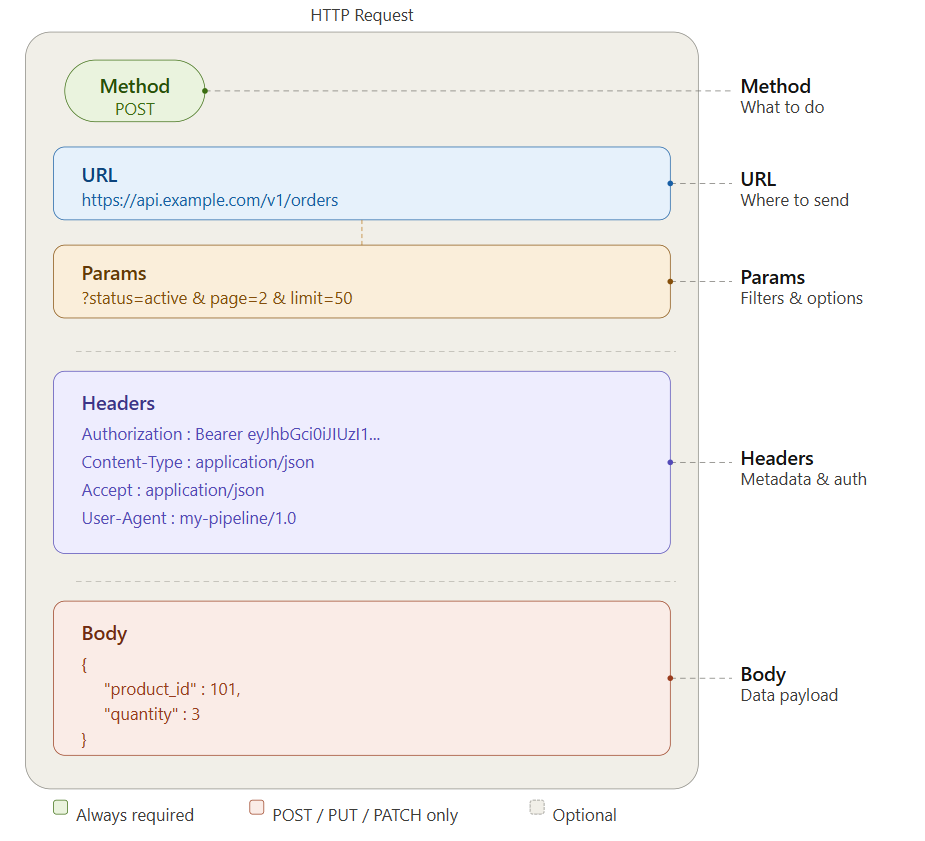

Headers are key-value pairs sent alongside every HTTP request and response to carry metadata i.e information about the request, not the data itself. They tell the server who you are (authentication), what format we are sending(Content-Type), what format we want back (Accept), and how to handle the connection. 

#### Authorization

Credentials to connect with API

Authorization: **Bearer** YOUR_TOKEN
<br> Authorization: **ApiKey** YOUR_KEY

An **API key** is a simple, static identifier used to authenticate a client. It is easy to use but less secure because it usually does not expire.

A **Bearer token** is a secure, temporary token (often generated after login) used to authorize requests. It expires after some time and can be revoked, making it more secure.

API key = basic identification
Bearer token = secure, temporary access

### Content-Type

Tells server what format you are sending

| Value                             | Meaning     |
| --------------------------------- | ----------- |
| application/json                  | JSON data   |
| multipart/form-data               | file upload |


### Accept

Tells server what format you want back

### User-agent
User-Agent is a request header that identifies who is making the request. It tells the server the name, type, and version of the client sending the request. For example In data pipelines, setting a descriptive User-Agent is considered good practice so API providers can identify your application.

In [30]:

url = "https://jsonplaceholder.typicode.com/posts"

headers = {
    "Authorization": "Bearer dummy_token",
    "Content-Type": "application/json",
    "Accept": "application/json",
    "User-Agent": "my_laptop"
}

params = {"userid":1, "_limit": 2}

response = requests.get(url, headers=headers, params=params)

print("Status:", response.status_code)
print("Headers:", response.headers) 

Status: 200
Headers: {'Date': 'Sun, 22 Mar 2026 09:49:42 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'access-control-allow-credentials': 'true', 'access-control-expose-headers': 'X-Total-Count', 'Cache-Control': 'no-cache', 'etag': 'W/"258-/AdFG/pwMUveUGKZ3vuwGAJYftA"', 'expires': '-1', 'nel': '{"report_to":"heroku-nel","response_headers":["Via"],"max_age":3600,"success_fraction":0.01,"failure_fraction":0.1}', 'pragma': 'no-cache', 'report-to': '{"group":"heroku-nel","endpoints":[{"url":"https://nel.heroku.com/reports?s=Ww4h0HqnsobodTydJJ6a8GBT5Wfw4PTwA3ZAAszx%2BCY%3D\\u0026sid=e11707d5-02a7-43ef-b45e-2cf4d2036f7d\\u0026ts=1774172982"}],"max_age":3600}', 'reporting-endpoints': 'heroku-nel="https://nel.heroku.com/reports?s=Ww4h0HqnsobodTydJJ6a8GBT5Wfw4PTwA3ZAAszx%2BCY%3D&sid=e11707d5-02a7-43ef-b45e-2cf4d2036f7d&ts=1774172982"', 'Server': 'cloudflare', 'vary': 'Origin, Accept-Encoding', 'via': '2.0 heroku-router', '

In [31]:
print("Data:", response.json())

Data: [{'userId': 1, 'id': 1, 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}, {'userId': 1, 'id': 2, 'title': 'qui est esse', 'body': 'est rerum tempore vitae\nsequi sint nihil reprehenderit dolor beatae ea dolores neque\nfugiat blanditiis voluptate porro vel nihil molestiae ut reiciendis\nqui aperiam non debitis possimus qui neque nisi nulla'}]
